https://www.nature.com/articles/s43588-021-00158-0

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

class NetStates(nn.Module):
    '''нейросеть для предсказывания SIRD'''
    def __init__(self, layers = [1, 200, 100, 4]):
        super().__init__()

        # TODO нужно подумать насчет кол-ва нейронов
        # почему не степень 2?
        self.fc1 = nn.Linear(1, 200)
        self.fc2 = nn.Linear(200, 100)
        self.out = nn.Linear(100, 4)

        # Инициализация Xavier
        nn.init.xavier_normal_(self.fc1.weight)
        nn.init.xavier_normal_(self.fc2.weight)
        nn.init.xavier_normal_(self.out.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.out.bias)

    def forward(self, t):
        x = torch.tanh(self.fc1(t))
        x = torch.tanh(self.fc2(x))
        return self.out(x)
    

class NetParameter(nn.Module):
    '''Нейросеть для параметра как функции от времени'''
    def __init__(self, layers = [1, 50, 50, 1]):
        super().__init__()

        self.fc1 = nn.Linear(1, 50)
        self.fc2 = nn.Linear(50, 50)
        self.out = nn.Linear(50, 1)

        nn.init.xavier_normal_(self.fc1.weight)
        nn.init.xavier_normal_(self.fc2.weight)
        nn.init.xavier_normal_(self.out.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.out.bias)

    def forward(self, t):
        x = torch.tanh(self.fc1(t))
        x = torch.tanh(self.fc2(x))
        return self.out(x)

class Nature_PINN(nn.Module):
    def __init__(self, t, S_data, I_data, R_data, D_data, device, train_size, population_n):
        super(Nature_PINN, self).__init__()

        self.device = device
        self.N = population_n
        self.train_size = train_size

        # Данные
        self.t = torch.tensor(t, requires_grad=True, device=self.device).float()
        self.t_batch = self.t.reshape(-1, 1)

        self.S = torch.tensor(S_data, device=device).float().reshape(-1, 1)
        self.I = torch.tensor(I_data, device=device).float().reshape(-1, 1)
        self.R = torch.tensor(R_data, device=device).float().reshape(-1, 1)
        self.D = torch.tensor(D_data, device=device).float().reshape(-1, 1)

        # Границы для масштабирования времени
        self.lb = torch.tensor(0, device=device).float()
        self.ub = torch.tensor(torch.max(self.t), device=device).float()

        # Масштабирование времение в [-1, 1] (как в статье)
        # self.t_scaled = 2.0 * (self.t_batch - self.lb) / (self.ub - self.lb) - 1.0

        # Нормализация данных
        self.S_max = self.S[:train_size].max()
        self.I_max = self.I[:train_size].max()
        self.D_max = self.D[:train_size].max()
        self.R_max = self.R[:train_size].max()
        self.S_min = self.S[:train_size].min()
        self.I_min = self.I[:train_size].min()
        self.D_min = self.D[:train_size].min()
        self.R_min = self.R[:train_size].min()
        
        self.S_hat = (self.S - self.S_min) / (self.S_max - self.S_min)
        self.I_hat = (self.I - self.I_min) / (self.I_max - self.I_min)
        self.D_hat = (self.D - self.D_min) / (self.D_max - self.D_min)
        self.R_hat = (self.R - self.R_min) / (self.R_max - self.R_min)

        # Инициализация сетей
        # Сеть для состояний
        self.net_states = NetStates().to(self.device)

        # Отдельные сети для параметров (как в статье)
        self.net_beta = NetParameter().to(self.device)
        self.net_gamma = NetParameter().to(self.device)
        self.net_mu = NetParameter().to(self.device)

        # Все обучаемые параметры
        self.params = (list(self.net_states.parameters()) + 
                       list(self.net_beta.parameters()) +
                       list(self.net_gamma.parameters()) +
                       list(self.net_mu.parameters()))
        
        # Для логирования
        self.losses = []

    @property
    def beta(self):
        '''β(t) в диапазоне [0, 1]'''
        return torch.sigmoid(self.net_beta(self.t_scaled))
    
    @property
    def gamma(self):
        '''γ(t) в диапазоне [0, 0.5] -- предполагается, что меньше 2-х дней люди не болеют'''
        return 0.5 * torch.sigmoid(self.net_gamma(self.t_scaled))
    
    @property
    def mu(self):
        '''μ(t) в диапазоне [0, 0.1] -- считаем, что летальность выше 10% маловероятна для гриппа'''
        return 0.1 * torch.sigmoid(self.net_mu(self.t_scaled))
    
    def net_f(self):
        '''ВЫчисление невязок'''
        t_batch = self.t_batch.clone().detach().requires_grad_(True)

        t_scaled = 2.0 * (t_batch - self.lb) / (self.ub - self.lb) - 1.0

        # Получение предсказания (нормализованные)
        states_hat = self.net_states(t_scaled)
        S_hat, I_hat, R_hat, D_hat = states_hat[:, 0:1], states_hat[:, 1:2], states_hat[:, 2:3], states_hat[:, 3:4]

        # Денормализация
        S = self.S_min + (self.S_max - self.S_min) * S_hat
        I = self.I_min + (self.I_max - self.I_min) * I_hat
        R = self.R_min + (self.R_max - self.R_min) * R_hat
        D = self.D_min + (self.D_max - self.D_min) * D_hat

        # Параметры эпидемии
        # beta =  self.beta
        # gamma = self.gamma
        # mu = self.mu

        # Производные нормализованных переменных
        S_hat_t = torch.autograd.grad(S_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        I_hat_t = torch.autograd.grad(I_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        R_hat_t = torch.autograd.grad(R_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        D_hat_t = torch.autograd.grad(D_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        
        # Восстановление оригинальных производных (в тетради\miro есть вывод формулы)
        S_t = (self.S_max - self.S_min) * S_hat_t
        I_t = (self.I_max - self.I_min) * I_hat_t
        R_t = (self.R_max - self.R_min) * R_hat_t
        D_t = (self.D_max - self.D_min) * D_hat_t

        beta = torch.sigmoid(self.net_beta(t_scaled)) + 0.01
        gamma = 0.5 * torch.sigmoid(self.net_gamma(t_scaled)) + 0.03 
        mu = 0.1 * torch.sigmoid(self.net_mu(t_scaled)) + 0.0001 

        # Уравнения SIRD
        dS = - beta * I * S / self.N
        dI = beta * I * S / self.N - gamma * I - mu * I
        dR = gamma * I
        dD = mu * I
        
        # Невязки в реальных масштабах
        f_S = S_t - dS
        f_I = I_t - dI
        f_R = R_t - dR
        f_D = D_t - dD

        # Conservation (как в статье)
        # TODO пока без этого попробую
        f_con = (S + I + R + D - self.N) / self.N  # можно нормализовать для loss

        # для ошибки по данным возьму нормализованные значения
        return f_S, f_I, f_R, f_D, S_hat, I_hat, R_hat, D_hat, beta, gamma, mu
    
    def loss_function(self):
        '''Вычисление функции потерь'''
        f_S, f_I, f_R, f_D, S_pred, I_pred, R_pred, D_pred, beta, gamma, mu = self.net_f()
    
        # Индексы для обучающей выборки
        idx = slice(self.train_size)

        # Ошибка на данных 
        loss_data = (1.0 * torch.mean((S_pred[idx] - self.S_hat[idx])**2) + 
                     1.0 * torch.mean((I_pred[idx] - self.I_hat[idx])**2) +
                     1.0 * torch.mean((R_pred[idx] - self.R_hat[idx])**2) +
                     1.0 * torch.mean((D_pred[idx] - self.D_hat[idx])**2))
        
        # Ошибка на начальных условиях
        # TODO пока отключу, это и так есть в невязке по данным
        loss_ic = (torch.mean((S_pred[0] - self.S_hat[0])**2) +
                   torch.mean((I_pred[0] - self.I_hat[0])**2) +
                   torch.mean((R_pred[0] - self.R_hat[0])**2) +
                   torch.mean((D_pred[0] - self.D_hat[0])**2))
        
        # Невязка по уравнениям SIRD
        loss_phys = (torch.mean(f_S**2) +
                     torch.mean(f_I**2) + 
                     torch.mean(f_R**2) +
                     torch.mean(f_D**2))
        
        # Регуляризация параметров (для гладкости)
        # TODO пока без этого, если значения будут прыгать, то включу
        # beta, gamma, mu = self.beta, self.gamma, self.mu
        loss_reg = (torch.mean((beta[1:] - beta[:-1])**2) +
                    torch.mean((gamma[1:] - gamma[:-1])**2) +
                    torch.mean((mu[1:] - mu[:-1])**2)) * 0.001
        
        # Итоговая потеря
        total_loss = (1.0 * loss_data +
                      1.0 * loss_phys)
        
        return total_loss, loss_data, loss_phys

    def train(self, n_epoch = 20000):
        '''Обучение модели'''
        print('\n' + '='*60)
        print('НАЧАЛО ОБУЧЕНИЯ')
        print('='*60)

        optimizer = optim.Adam(self.params, lr=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=1000
        )

        for epoch in range(n_epoch):
            optimizer.zero_grad()

            total_loss, loss_data, loss_phys = self.loss_function()
            total_loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.params, max_norm=1.0)

            optimizer.step()
            scheduler.step(total_loss)
            
            self.losses.append(total_loss.item())

            if epoch % 1000 == 0:
                print(f'\nЭпоха {epoch:5d}:')
                print(f'  Total Loss: {total_loss.item():.2e}')
                print(f'  Data Loss: {loss_data.item():.2e}')
                print(f'  Physics Loss: {loss_phys.item():.2e}')
                
                # Статистика параметров
                with torch.no_grad():

                    t_batch = self.t_batch
                    t_scaled = 2.0 * (t_batch - self.lb) / (self.ub - self.lb) - 1.0

                    beta = torch.sigmoid(self.net_beta(t_scaled)) + 0.01
                    gamma = 0.5 * torch.sigmoid(self.net_gamma(t_scaled)) + 0.03 
                    mu = 0.1 * torch.sigmoid(self.net_mu(t_scaled)) + 0.0001 

                    beta_mean = beta.mean().item()
                    gamma_mean = gamma.mean().item()
                    mu_mean = mu.mean().item()

                    print(f'  β mean: {beta_mean:.4f} [min: {beta.min().item():.4f}, max: {beta.max().item():.4f}]')
                    print(f'  γ mean: {gamma_mean:.4f} [min: {gamma.min().item():.4f}, max: {gamma.max().item():.4f}]')
                    print(f'  μ mean: {mu_mean:.4f} [min: {mu.min().item():.4f}, max: {mu.max().item():.4f}]')


    def predict(self, t_new = None):
        '''Предсказания'''
        if t_new is None:
            t_tensor = self.t_batch
        else:
            t_tensor = torch.tensor(t_new, device=self.device).float().reshape(-1, 1)
        t_scaled = 2.0 * (t_tensor - self.lb) / (self.ub - self.lb) - 1.0

        with torch.no_grad():
            states_hat = self.net_states(t_scaled)
            S_hat, I_hat, R_hat, D_hat = states_hat[:, 0], states_hat[:, 1], states_hat[:, 2], states_hat[:, 3]

            # Денормализация
            S = self.S_min + (self.S_max - self.S_min) * S_hat
            I = self.I_min + (self.I_max - self.I_min) * I_hat
            R = self.R_min + (self.R_max - self.R_min) * R_hat
            D = self.D_min + (self.D_max - self.D_min) * D_hat

            # Параметры (t_scaled могут быть новыми, поэтому не property вызов)
            beta = torch.sigmoid(self.net_beta(t_scaled)).flatten() + 0.01
            gamma = 0.5 * torch.sigmoid(self.net_gamma(t_scaled)).flatten() + 0.03
            mu = 0.1 * torch.sigmoid(self.net_mu(t_scaled)).flatten() + 0.0001

        return {
            'S': S.cpu().detach().numpy(),
            'I': I.cpu().detach().numpy(),
            'R': R.cpu().detach().numpy(),
            'D': D.cpu().detach().numpy(),
            'beta': beta.cpu().detach().numpy(),
            'gamma': gamma.cpu().detach().numpy(),
            'mu': mu.cpu().detach().numpy(),
            't': t_tensor.cpu().detach().numpy().flatten()
        }



In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определяем девайс: cuda если есть, иначе cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True

# Загрузка данных
covid_cases = pd.read_csv('sird_data_01_006_0003.csv')
# covid_cases = pd.read_csv('simulation.csv')

# Получаем данные
S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values
timesteps = np.arange(len(S)).astype(float)

# Параметры
train_size = 101  # размер обучающей выборки
population = 1000  # население (подберите под ваши данные)

print(f"Всего точек данных: {len(timesteps)}")
print(f"Обучающих точек: {train_size}")
print(f"Тестовых точек: {len(timesteps) - train_size}")

Using device: cuda
Всего точек данных: 366
Обучающих точек: 101
Тестовых точек: 265


In [14]:
# Создание модели
model = Nature_PINN(
    t=timesteps,
    S_data=S,
    I_data=I,
    D_data=D,
    R_data=R,
    device=device,
    train_size=train_size,
    population_n=population
)

# ============================================================
# ОБУЧЕНИЕ МОДЕЛИ
# ============================================================

# Обучаем модель
model.train(n_epoch=20000)

# ============================================================
# ПОЛУЧЕНИЕ ПРОГНОЗА
# ============================================================

# Вариант 1: Прогноз на все временные точки (обучение + тест)
predictions = model.predict()  # без аргументов - использует все обучающие точки

# Извлекаем результаты
S_pred = predictions['S']
I_pred = predictions['I']
R_pred = predictions['R']
D_pred = predictions['D']
beta_pred = predictions['beta']
gamma_pred = predictions['gamma']
mu_pred = predictions['mu']
t_pred = predictions['t']

C:\Users\dinara\AppData\Local\Temp\ipykernel_15028\3925217506.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.ub = torch.tensor(torch.max(self.t), device=device).float()



НАЧАЛО ОБУЧЕНИЯ

Эпоха     0:
  Total Loss: 2.04e+00
  Data Loss: 1.14e+00
  Physics Loss: 8.91e-01
  β mean: 0.5096 [min: 0.4457, max: 0.5734]
  γ mean: 0.2798 [min: 0.2614, max: 0.2983]
  μ mean: 0.0501 [min: 0.0493, max: 0.0510]

Эпоха  1000:
  Total Loss: 9.84e-02
  Data Loss: 9.37e-02
  Physics Loss: 4.68e-03
  β mean: 0.0593 [min: 0.0434, max: 0.0905]
  γ mean: 0.0464 [min: 0.0329, max: 0.0853]
  μ mean: 0.0037 [min: 0.0021, max: 0.0065]

Эпоха  2000:
  Total Loss: 4.15e-02
  Data Loss: 3.76e-02
  Physics Loss: 3.94e-03
  β mean: 0.0499 [min: 0.0290, max: 0.1468]
  γ mean: 0.0392 [min: 0.0300, max: 0.1257]
  μ mean: 0.0019 [min: 0.0004, max: 0.0062]

Эпоха  3000:
  Total Loss: 3.55e-03
  Data Loss: 2.83e-03
  Physics Loss: 7.22e-04
  β mean: 0.0563 [min: 0.0167, max: 0.1796]
  γ mean: 0.0435 [min: 0.0302, max: 0.1231]
  μ mean: 0.0019 [min: 0.0002, max: 0.0088]

Эпоха  4000:
  Total Loss: 8.40e-04
  Data Loss: 6.34e-04
  Physics Loss: 2.06e-04
  β mean: 0.0603 [min: 0.0173, max:


ГРАФИКИ ПРЕДСКАЗАНИЙ SIRD
График сохранен в sird_results_sird.png


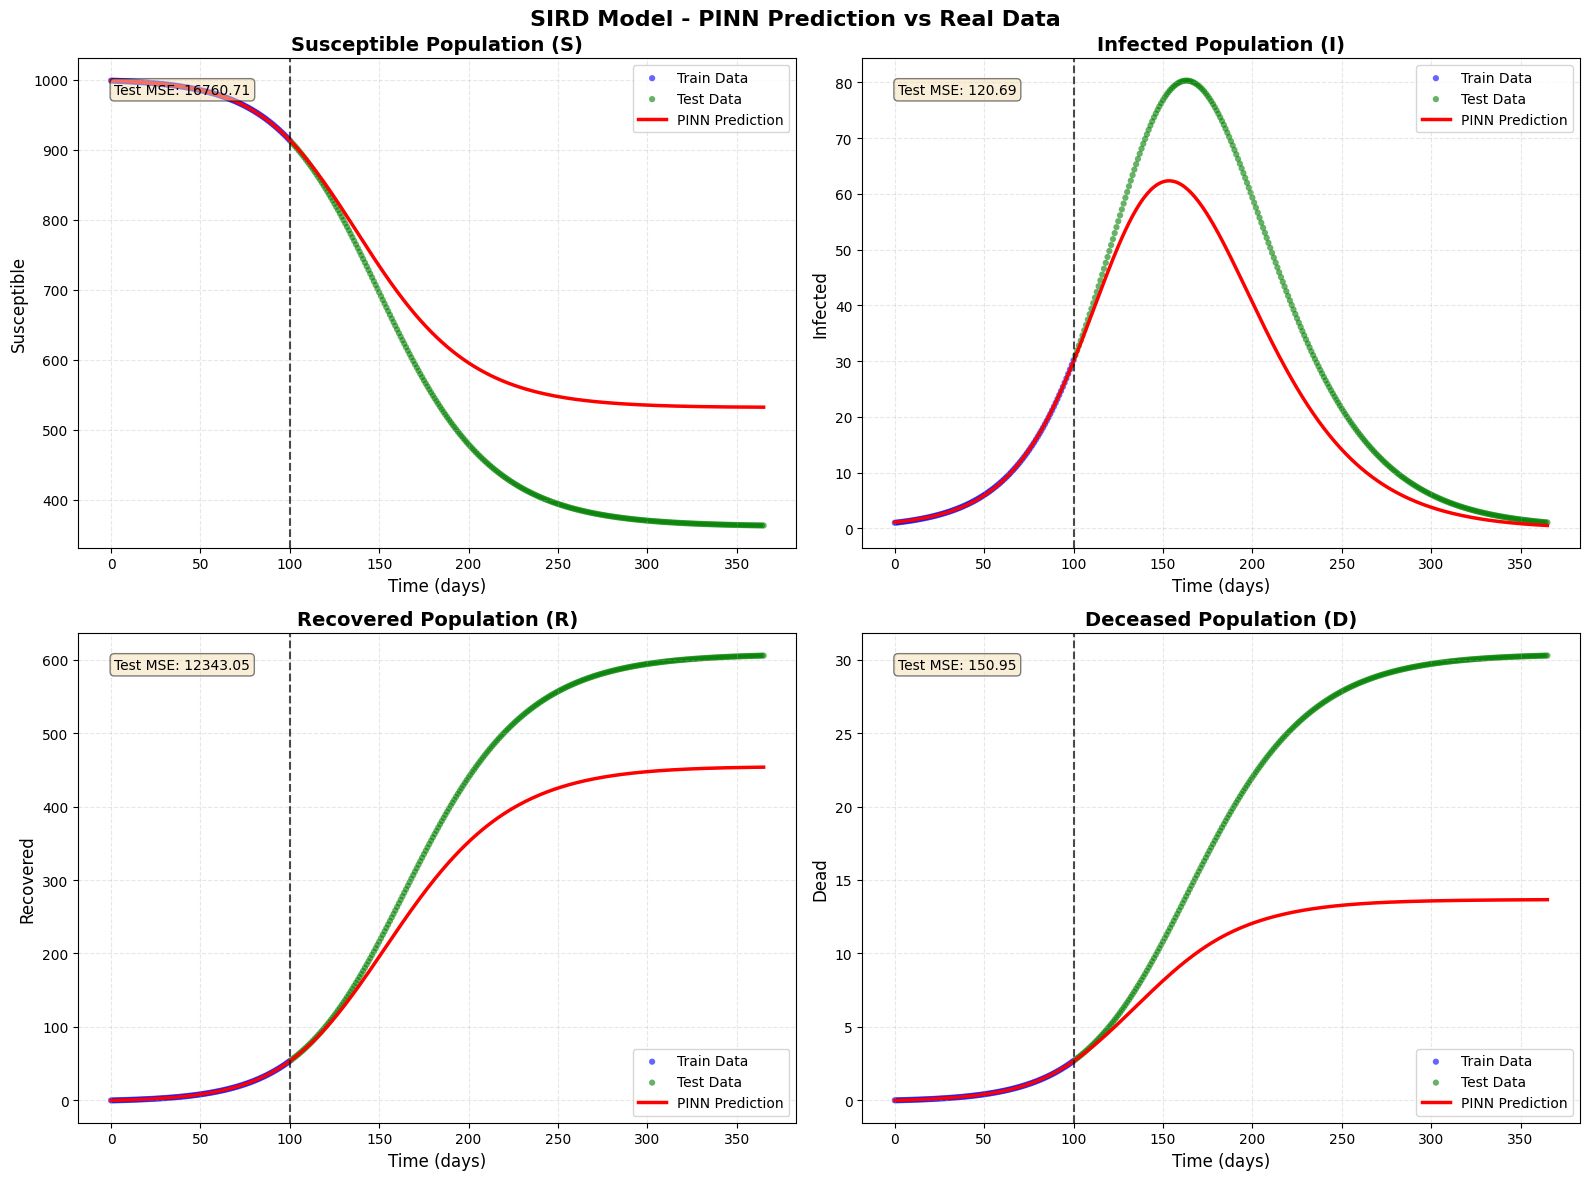


ГРАФИКИ ПАРАМЕТРОВ МОДЕЛИ
График параметров сохранен в sird_results_parameters.png


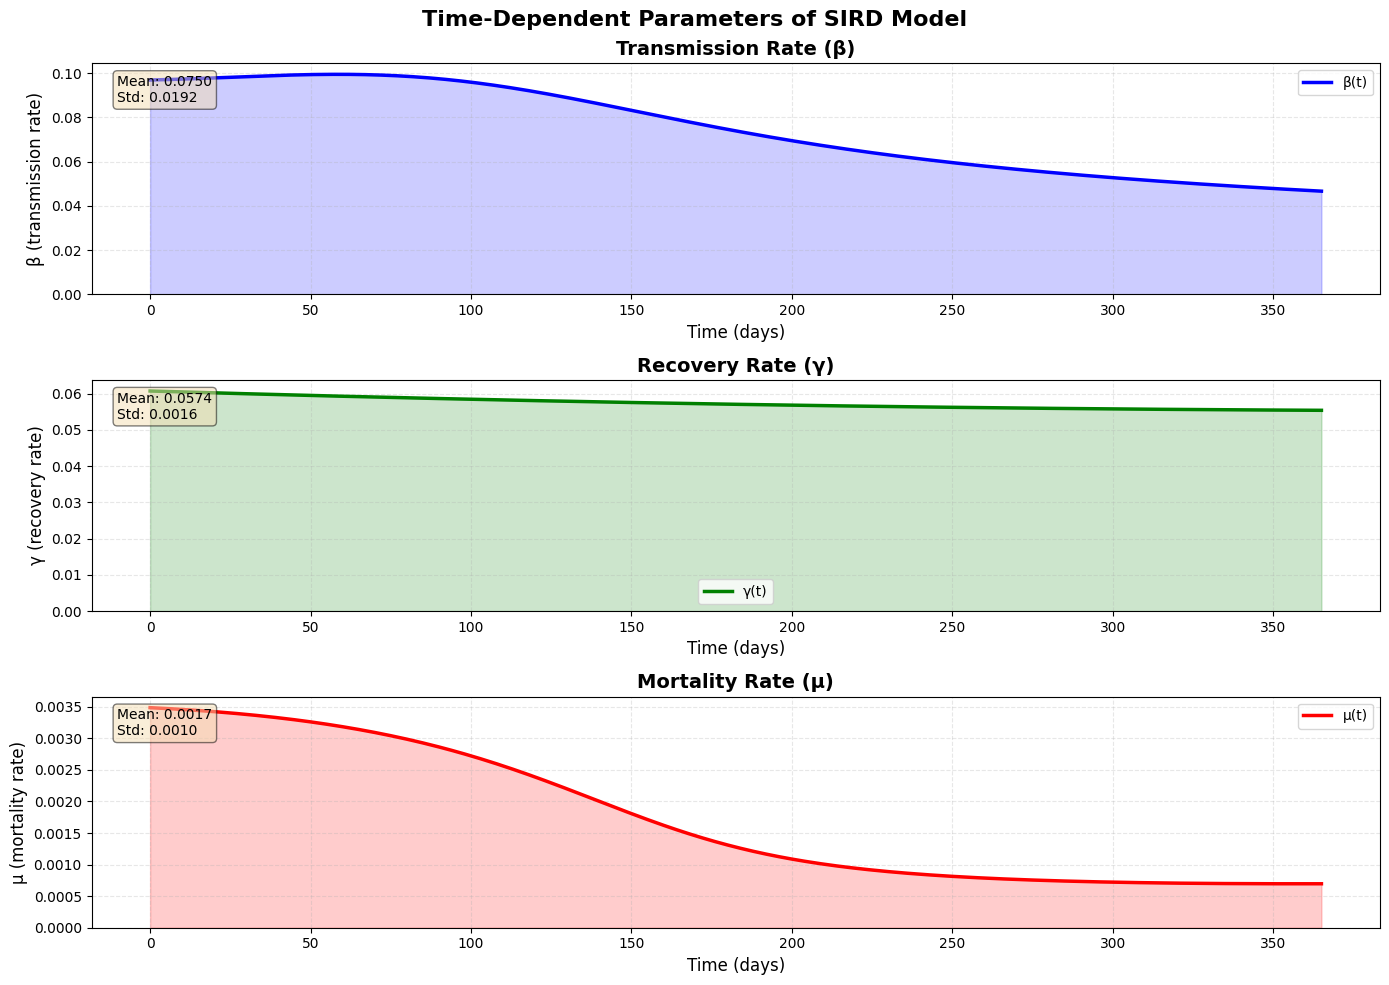


ГРАФИК ПОТЕРЬ
График потерь сохранен в sird_results_loss.png


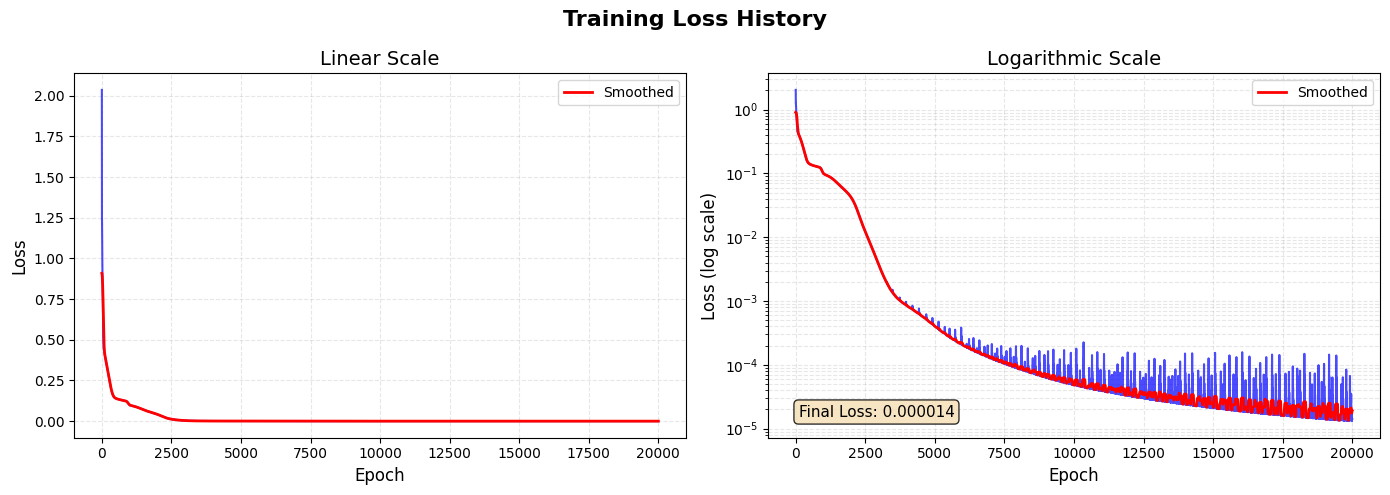


МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
S:
  MSE:  16760.7149
  MAE:  115.0485
  RMSE: 129.4632
  MAPE: 28.46%
I:
  MSE:  120.6912
  MAE:  8.2867
  RMSE: 10.9860
  MAPE: 30.46%
R:
  MSE:  12343.0461
  MAE:  96.0412
  RMSE: 111.0993
  MAPE: 18.55%
D:
  MSE:  150.9460
  MAE:  10.7007
  RMSE: 12.2860
  MAPE: 41.85%


In [15]:
# Функция для отрисовки результатов SIRD
def plot_sird_results(timesteps, train_size, 
                      S_data, I_data, R_data, D_data,
                      S_pred, I_pred, R_pred, D_pred,
                      save_path=None):
    """
    Отображение результатов предсказания SIRD модели
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('SIRD Model - PINN Prediction vs Real Data', fontsize=16, fontweight='bold')
    
    # Вертикальная линия разделяющая train/test
    train_test_line = timesteps[train_size - 1] if train_size < len(timesteps) else timesteps[-1]
    
    # Цвета
    colors = {
        'train': 'blue',
        'test': 'green',
        'pred': 'red',
        'split': 'black'
    }
    
    # 1. Susceptible (S)
    ax = axes[0, 0]
    ax.scatter(timesteps[:train_size], S_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], S_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, S_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Susceptible', fontsize=12)
    ax.set_title('Susceptible Population (S)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Добавляем текст с метриками
    if train_size < len(timesteps):
        mse_test = np.mean((S_data[train_size:] - S_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Infected (I)
    ax = axes[0, 1]
    ax.scatter(timesteps[:train_size], I_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], I_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, I_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Infected', fontsize=12)
    ax.set_title('Infected Population (I)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if train_size < len(timesteps):
        mse_test = np.mean((I_data[train_size:] - I_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 3. Recovered (R)
    ax = axes[1, 0]
    ax.scatter(timesteps[:train_size], R_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], R_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, R_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Recovered', fontsize=12)
    ax.set_title('Recovered Population (R)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if train_size < len(timesteps):
        mse_test = np.mean((R_data[train_size:] - R_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 4. Dead (D)
    ax = axes[1, 1]
    ax.scatter(timesteps[:train_size], D_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], D_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, D_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Dead', fontsize=12)
    ax.set_title('Deceased Population (D)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if train_size < len(timesteps):
        mse_test = np.mean((D_data[train_size:] - D_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранен в {save_path}")
    
    plt.show()
    
    return fig

# Функция для отрисовки параметров во времени
def plot_parameters_over_time(t_pred, beta_pred, gamma_pred, mu_pred, save_path=None):
    """
    Отображение изменения параметров модели во времени
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle('Time-Dependent Parameters of SIRD Model', fontsize=16, fontweight='bold')
    
    # Бета (коэффициент заражения)
    ax = axes[0]
    ax.plot(t_pred, beta_pred, 'b-', linewidth=2.5, label='β(t)')
    ax.fill_between(t_pred, 0, beta_pred, alpha=0.2, color='blue')
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('β (transmission rate)', fontsize=12)
    ax.set_title('Transmission Rate (β)', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)
    
    # Статистика
    ax.text(0.02, 0.95, f'Mean: {beta_pred.mean():.4f}\nStd: {beta_pred.std():.4f}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Гамма (коэффициент выздоровления)
    ax = axes[1]
    ax.plot(t_pred, gamma_pred, 'g-', linewidth=2.5, label='γ(t)')
    ax.fill_between(t_pred, 0, gamma_pred, alpha=0.2, color='green')
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('γ (recovery rate)', fontsize=12)
    ax.set_title('Recovery Rate (γ)', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)
    
    ax.text(0.02, 0.95, f'Mean: {gamma_pred.mean():.4f}\nStd: {gamma_pred.std():.4f}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Мю (коэффициент смертности)
    ax = axes[2]
    ax.plot(t_pred, mu_pred, 'r-', linewidth=2.5, label='μ(t)')
    ax.fill_between(t_pred, 0, mu_pred, alpha=0.2, color='red')
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('μ (mortality rate)', fontsize=12)
    ax.set_title('Mortality Rate (μ)', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)
    
    ax.text(0.02, 0.95, f'Mean: {mu_pred.mean():.4f}\nStd: {mu_pred.std():.4f}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График параметров сохранен в {save_path}")
    
    plt.show()
    
    return fig

# Функция для отрисовки потерь
def plot_losses(losses, save_path=None):
    """
    Отображение кривой обучения
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training Loss History', fontsize=16, fontweight='bold')
    
    epochs = np.arange(len(losses))
    
    # Линейный масштаб
    ax = axes[0]
    ax.plot(epochs, losses, 'b-', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Linear Scale', fontsize=14)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Сглаженная кривая для линейного масштаба
    if len(losses) > 100:
        from scipy.ndimage import uniform_filter1d
        smoothed = uniform_filter1d(losses, size=100)
        ax.plot(epochs, smoothed, 'r-', linewidth=2, label='Smoothed')
        ax.legend()
    
    # Логарифмический масштаб
    ax = axes[1]
    ax.semilogy(epochs, losses, 'b-', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss (log scale)', fontsize=12)
    ax.set_title('Logarithmic Scale', fontsize=14)
    ax.grid(True, alpha=0.3, linestyle='--', which='both')
    
    # Сглаженная кривая для логарифмического масштаба
    if len(losses) > 100:
        ax.semilogy(epochs, smoothed, 'r-', linewidth=2, label='Smoothed')
        ax.legend()
    
    # Добавляем информацию о финальной ошибке
    ax.text(0.05, 0.05, f'Final Loss: {losses[-1]:.6f}', 
            transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График потерь сохранен в {save_path}")
    
    plt.show()
    
    return fig

# Функция для вычисления метрик
def calculate_metrics(S_data, I_data, R_data, D_data, 
                     S_pred, I_pred, R_pred, D_pred, train_size):
    """
    Вычисление метрик качества на тестовой выборке
    """
    if train_size >= len(S_data):
        print("Внимание: train_size больше или равен длине данных. Метрики считаются на всех данных.")
        test_mask = slice(None)
    else:
        test_mask = slice(train_size, None)
    
    # Метрики
    metrics = {}
    names = ['S', 'I', 'R', 'D']
    data = [S_data, I_data, R_data, D_data]
    pred = [S_pred, I_pred, R_pred, D_pred]
    
    print("\n" + "="*70)
    print("МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
    print("="*70)
    
    for name, d, p in zip(names, data, pred):
        # MSE
        mse = np.mean((d[test_mask] - p[test_mask])**2)
        # MAE
        mae = np.mean(np.abs(d[test_mask] - p[test_mask]))
        # RMSE
        rmse = np.sqrt(mse)
        # MAPE (избегаем деления на ноль)
        with np.errstate(divide='ignore', invalid='ignore'):
            mape = np.mean(np.abs((d[test_mask] - p[test_mask]) / (d[test_mask] + 1e-10))) * 100
        
        metrics[name] = {
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'mape': mape
        }
        
        print(f"{name}:")
        print(f"  MSE:  {mse:.4f}")
        print(f"  MAE:  {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAPE: {mape:.2f}%")
    
    print("="*70)
    
    return metrics

# Функция для отрисовки всех графиков вместе
def plot_all_results(timesteps, train_size,
                    S_data, I_data, R_data, D_data,
                    predictions, losses,
                    save_prefix=None):
    """
    Отображение всех графиков
    """
    # 1. Графики SIRD
    print("\n" + "="*70)
    print("ГРАФИКИ ПРЕДСКАЗАНИЙ SIRD")
    print("="*70)
    
    fig1 = plot_sird_results(
        timesteps, train_size,
        S_data, I_data, R_data, D_data,
        predictions['S'], predictions['I'], 
        predictions['R'], predictions['D'],
        save_path=f"{save_prefix}_sird.png" if save_prefix else None
    )
    
    # 2. Графики параметров
    print("\n" + "="*70)
    print("ГРАФИКИ ПАРАМЕТРОВ МОДЕЛИ")
    print("="*70)
    
    fig2 = plot_parameters_over_time(
        predictions['t'], 
        predictions['beta'],
        predictions['gamma'],
        predictions['mu'],
        save_path=f"{save_prefix}_parameters.png" if save_prefix else None
    )
    
    # 3. График потерь
    print("\n" + "="*70)
    print("ГРАФИК ПОТЕРЬ")
    print("="*70)
    
    fig3 = plot_losses(
        losses,
        save_path=f"{save_prefix}_loss.png" if save_prefix else None
    )
    
    # 4. Метрики
    metrics = calculate_metrics(
        S_data, I_data, R_data, D_data,
        predictions['S'], predictions['I'],
        predictions['R'], predictions['D'],
        train_size
    )
    
    return fig1, fig2, fig3, metrics


losses = model.losses  # или model.train_losses, в зависимости от реализации

# Отображаем все графики
fig1, fig2, fig3, metrics = plot_all_results(
    timesteps=timesteps,
    train_size=train_size,
    S_data=S,
    I_data=I,
    R_data=R,
    D_data=D,
    predictions=predictions,
    losses=losses,
    save_prefix='sird_results'  # опционально, для сохранения файлов
)